<strong>IRIS FLOWER CLASSIFICATION</strong>

In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')


plt.style.use("fivethirtyeight")
%matplotlib inline

In [3]:
df=pd.read_csv("data/iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
#information about the dataset
df.info()   

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


In [5]:
#describing about the dataset
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df.shape

(150, 6)

### We drop the column id because it is not important.

In [7]:
df.drop('Id',axis=1,inplace=True)

In [8]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
#count the value
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [10]:
#finding the null value
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [34]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)

# EDA 

### 1. Relationship between species and sepal length

<Axes: xlabel='Species', ylabel='SepalLengthCm'>

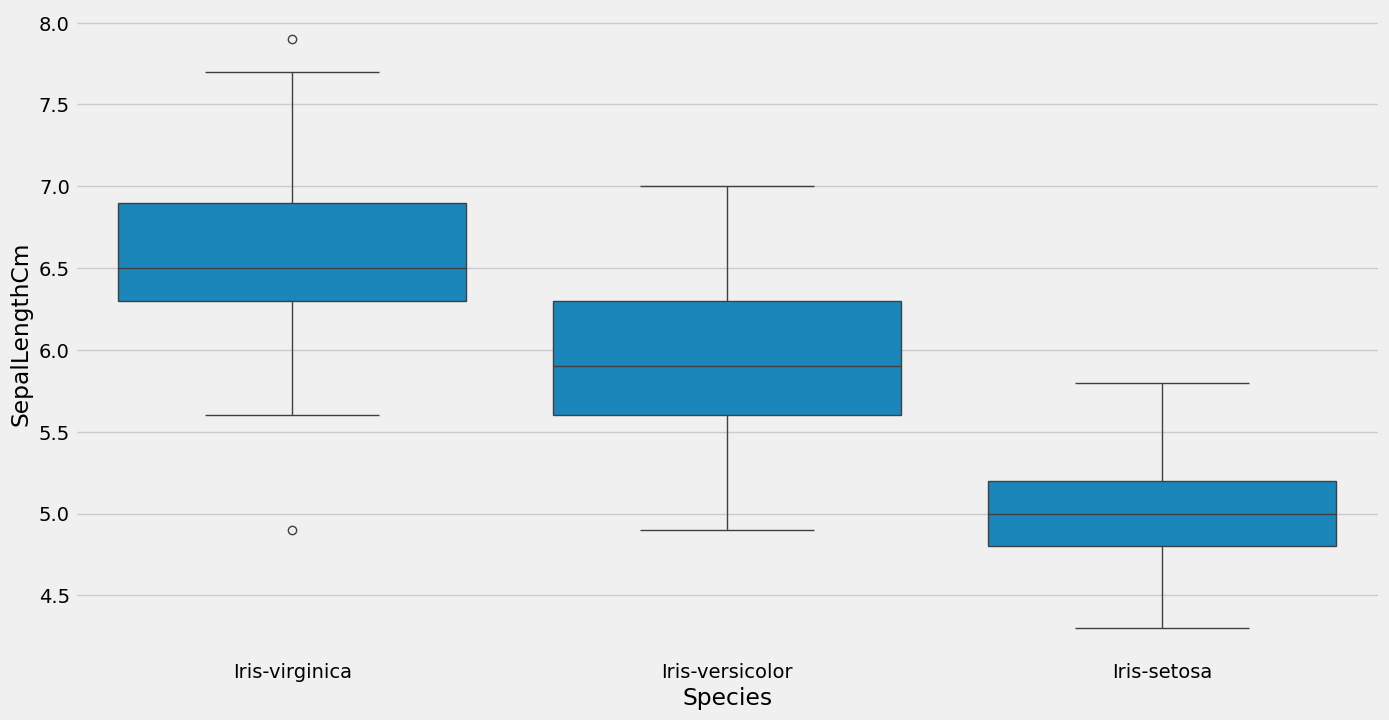

In [13]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Species',y='SepalLengthCm',data=df.sort_values('SepalLengthCm',ascending=False))

### 2. Relationship between species and sepal width

<Axes: xlabel='SepalWidthCm', ylabel='SepalLengthCm'>

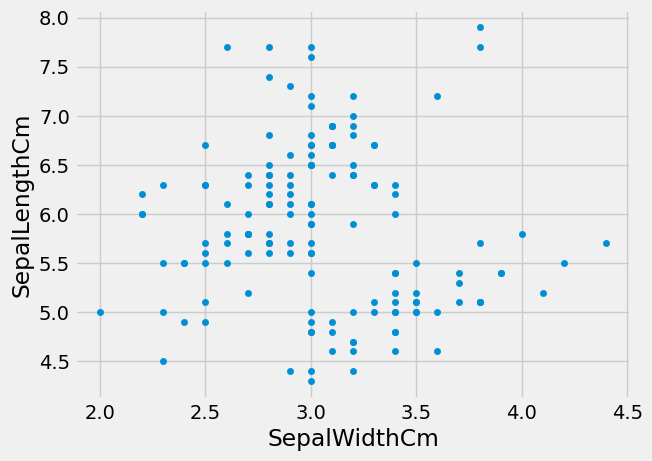

In [14]:
df.plot(kind='scatter',x='SepalWidthCm',y='SepalLengthCm')

### 3. Relationship between sepal width and sepal length

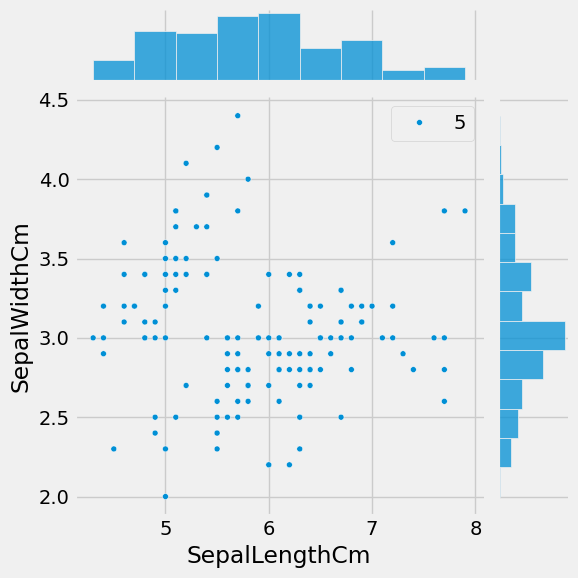

In [15]:
sns.jointplot(x="SepalLengthCm", y="SepalWidthCm", data=df, size=5)

### 4.Pairplot

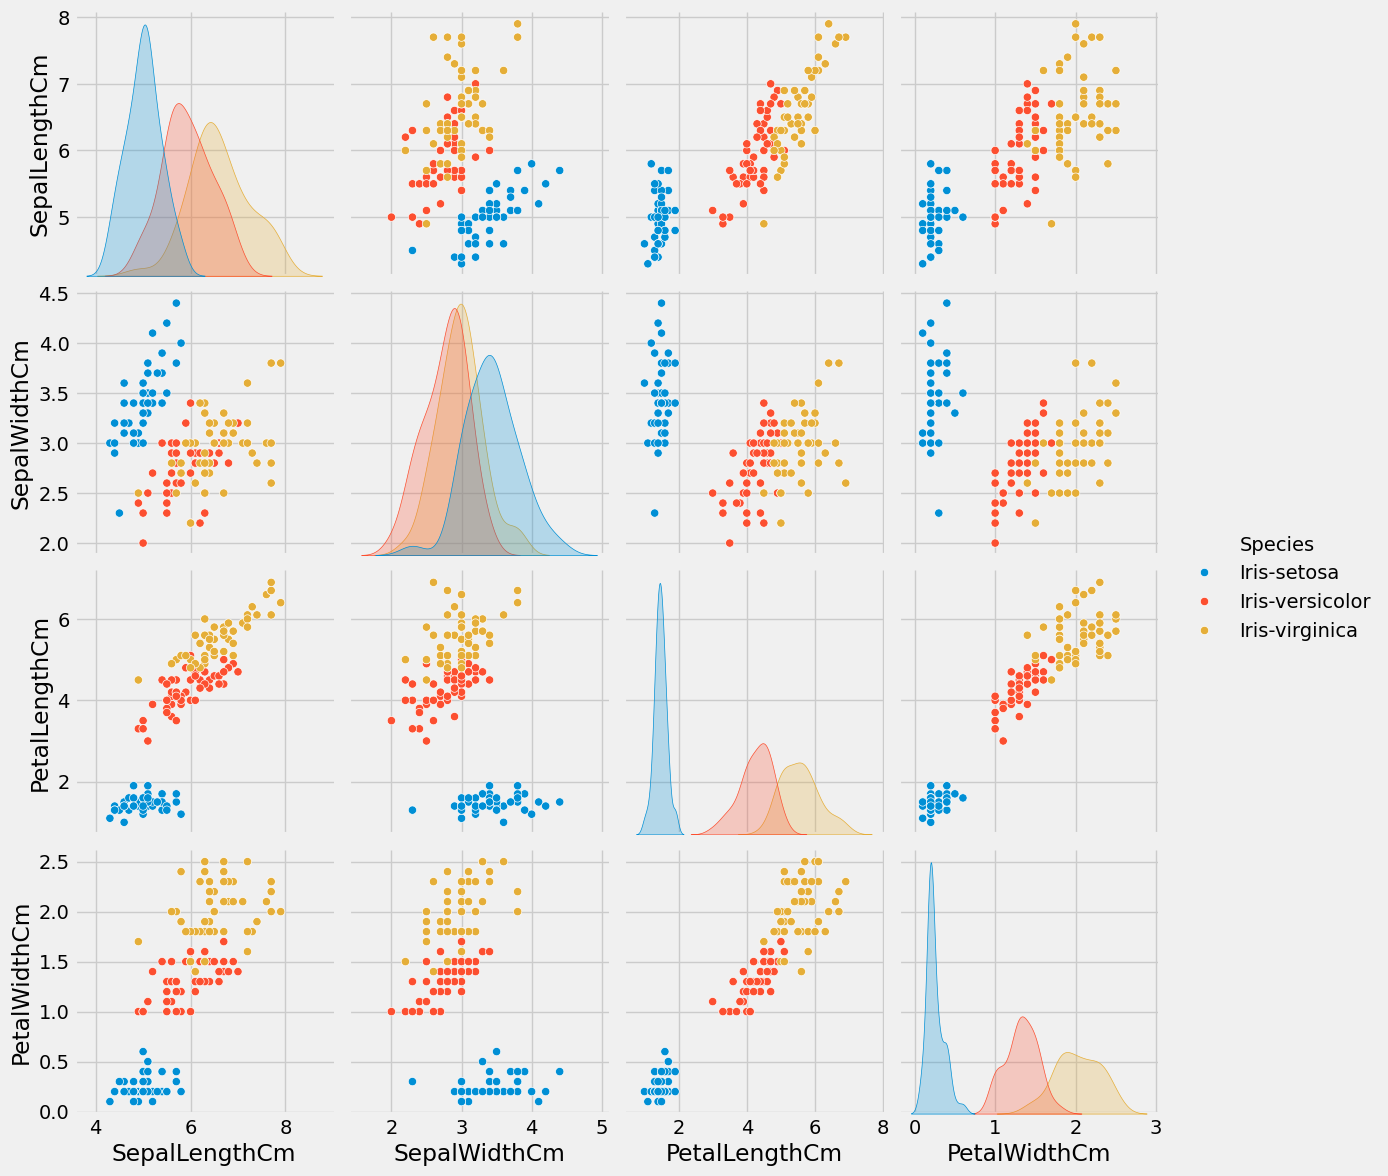

In [16]:
sns.pairplot(df, hue="Species", size=3)

### 5. Boxplot

array([[<Axes: title={'center': 'PetalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'PetalWidthCm'}, xlabel='[Species]'>],
       [<Axes: title={'center': 'SepalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'SepalWidthCm'}, xlabel='[Species]'>]],
      dtype=object)

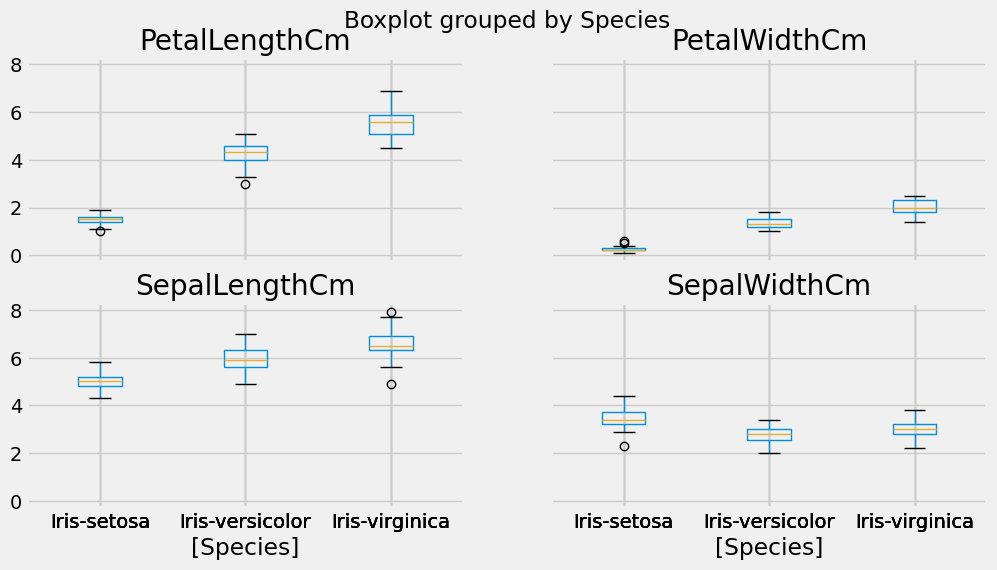

In [17]:
df.boxplot(by="Species", figsize=(12, 6))

### 5. Andrews_curves

<Axes: >

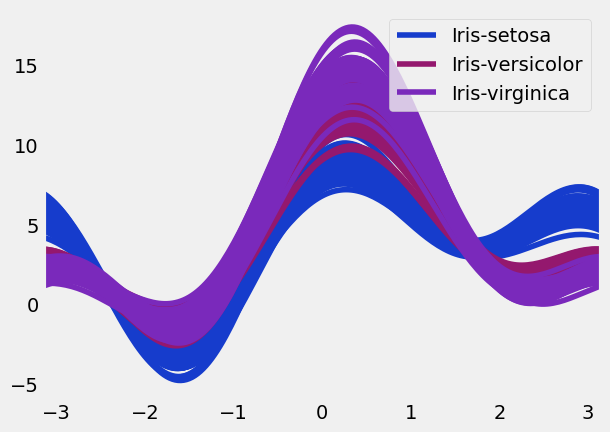

In [18]:
import pandas.plotting
from pandas.plotting import andrews_curves
andrews_curves(df, "Species")

### 6.CategoricalPlot

<Figure size 1500x1500 with 0 Axes>

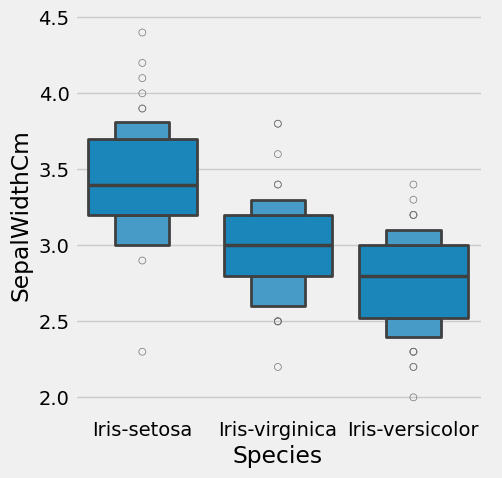

In [19]:
plt.figure(figsize=(15,15))
sns.catplot(x='Species',y='SepalWidthCm',data=df.sort_values('SepalWidthCm',ascending=False),kind='boxen')

### 7.Violinplot

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

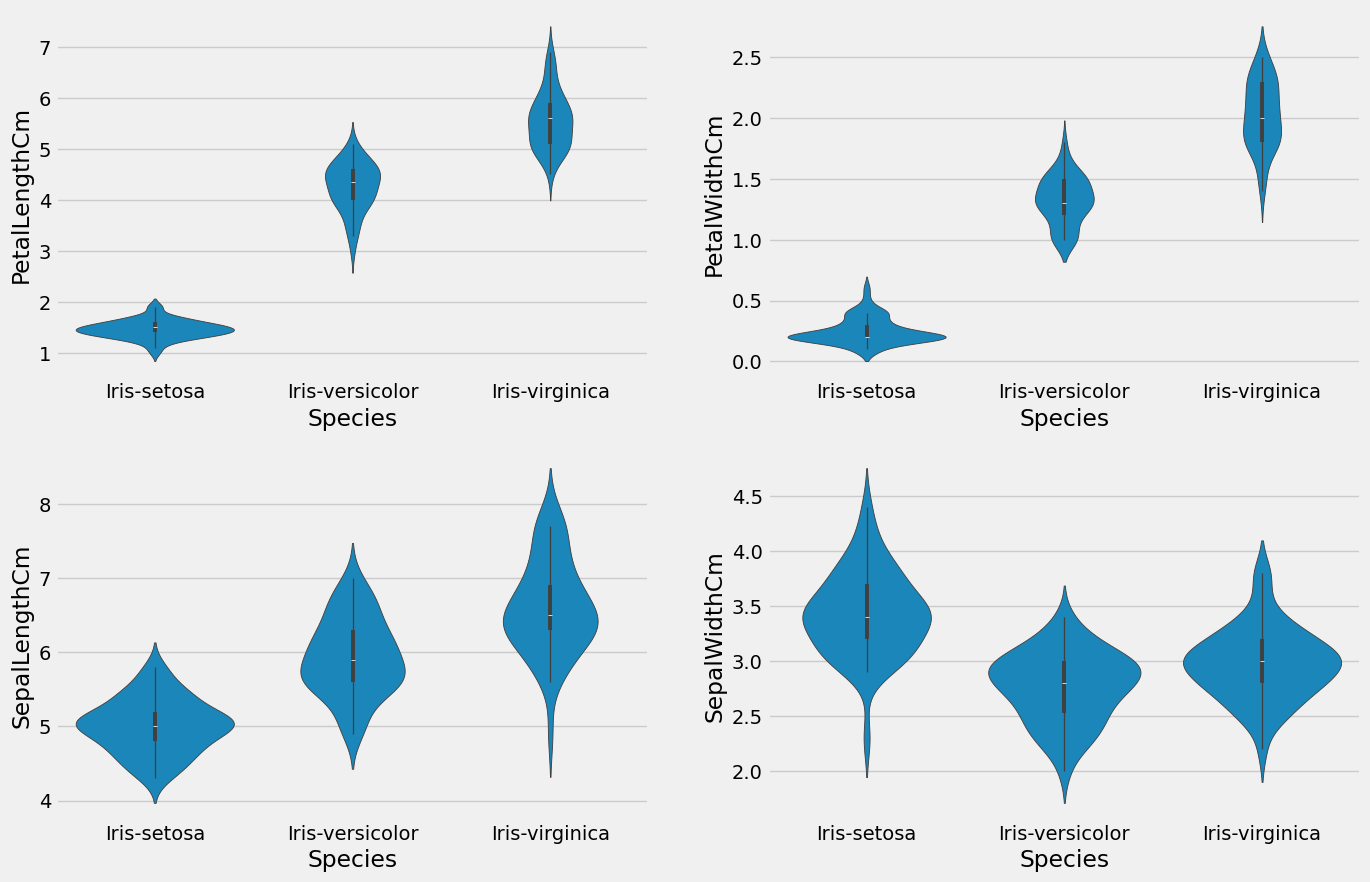

In [20]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.violinplot(x='Species',y='PetalLengthCm',data=df)
plt.subplot(2,2,2)
sns.violinplot(x='Species',y='PetalWidthCm',data=df)
plt.subplot(2,2,3)
sns.violinplot(x='Species',y='SepalLengthCm',data=df)
plt.subplot(2,2,4)
sns.violinplot(x='Species',y='SepalWidthCm',data=df)

# Neural Network

In [21]:
X=df.drop('Species',axis=1)
y=df['Species']


In [22]:
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

In [23]:
df['Species'] = pd.Categorical(df.Species)
df['Species'] = df.Species.cat.codes
# Turn response variable into one-hot response vectory = to_categorical(df.response)
y = to_categorical(df.Species)


In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,stratify=y,random_state=123)

In [25]:
model=Sequential()
model.add(Dense(100,activation='relu',input_shape=(4,)))

model.add(Dense(3,activation='softmax'))

In [26]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [27]:
history=model.fit(X_train,y_train,epochs=45,validation_data=(X_test, y_test))

Epoch 1/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.2451 - loss: 1.6212 - val_accuracy: 0.3111 - val_loss: 1.5448
Epoch 2/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2255 - loss: 1.4804 - val_accuracy: 0.2667 - val_loss: 1.4186
Epoch 3/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2451 - loss: 1.3726 - val_accuracy: 0.3556 - val_loss: 1.3237
Epoch 4/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2255 - loss: 1.2993 - val_accuracy: 0.3111 - val_loss: 1.2529
Epoch 5/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2549 - loss: 1.2283 - val_accuracy: 0.3778 - val_loss: 1.1931
Epoch 6/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2549 - loss: 1.1803 - val_accuracy: 0.3556 - val_loss: 1.1386
Epoch 7/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2451 - loss: 1.1317 - val_accuracy: 0.3333 - val_loss: 1.0964
Epoch 8/45
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3137 - loss: 1.0943 - val_accuracy: 0.3333 - val_loss: 1.0582

In [28]:
model.evaluate(X_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9333 - loss: 0.4375


[0.4375282824039459, 0.9333333373069763]

In [29]:
pred = model.predict(X_test[:10])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[[0.01259345 0.3455002  0.6419063 ]
 [0.01020619 0.36371636 0.6260775 ]
 [0.08760845 0.517636   0.39475557]
 [0.0551135  0.51043206 0.43445447]
 [0.8795313  0.08794443 0.03252428]
 [0.05201939 0.5290759  0.4189047 ]
 [0.01210919 0.3199052  0.6679857 ]
 [0.01324095 0.32789612 0.65886295]
 [0.88260037 0.08552355 0.03187606]
 [0.02489405 0.3508105  0.6242955 ]]


In [30]:
p=np.argmax(pred,axis=1)
print(p)
print(y_test[:10])

[2 2 1 1 0 1 2 2 0 2]
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [31]:
history.history['accuracy']

[0.2450980395078659,
 0.22549019753932953,
 0.2450980395078659,
 0.22549019753932953,
 0.2549019753932953,
 0.2549019753932953,
 0.2450980395078659,
 0.3137255012989044,
 0.3235294222831726,
 0.3235294222831726,
 0.3137255012989044,
 0.4803921580314636,
 0.6470588445663452,
 0.6666666865348816,
 0.6666666865348816,
 0.686274528503418,
 0.6764705777168274,
 0.6764705777168274,
 0.6764705777168274,
 0.6666666865348816,
 0.656862735748291,
 0.656862735748291,
 0.656862735748291,
 0.656862735748291,
 0.7352941036224365,
 0.9215686321258545,
 0.8725489974021912,
 0.7156862616539001,
 0.6666666865348816,
 0.6666666865348816,
 0.6764705777168274,
 0.8039215803146362,
 0.9411764740943909,
 0.9607843160629272,
 0.9607843160629272,
 0.9509803652763367,
 0.8725489974021912,
 0.7549019455909729,
 0.7156862616539001,
 0.8333333134651184,
 0.8529411554336548,
 0.8823529481887817,
 0.8529411554336548,
 0.8529411554336548,
 0.9019607901573181]

In [32]:
history.history['val_accuracy']

[0.31111112236976624,
 0.2666666805744171,
 0.35555556416511536,
 0.31111112236976624,
 0.3777777850627899,
 0.35555556416511536,
 0.3333333432674408,
 0.3333333432674408,
 0.3333333432674408,
 0.3333333432674408,
 0.3777777850627899,
 0.6666666865348816,
 0.6666666865348816,
 0.6888889074325562,
 0.7111111283302307,
 0.7111111283302307,
 0.6888889074325562,
 0.6888889074325562,
 0.6888889074325562,
 0.6666666865348816,
 0.6666666865348816,
 0.6666666865348816,
 0.6666666865348816,
 0.7333333492279053,
 0.8888888955116272,
 0.8888888955116272,
 0.800000011920929,
 0.6888889074325562,
 0.6888889074325562,
 0.7111111283302307,
 0.7777777910232544,
 0.8888888955116272,
 0.9333333373069763,
 0.9111111164093018,
 0.9333333373069763,
 0.8666666746139526,
 0.7777777910232544,
 0.7333333492279053,
 0.800000011920929,
 0.8444444537162781,
 0.8666666746139526,
 0.8444444537162781,
 0.800000011920929,
 0.8444444537162781,
 0.9333333373069763]

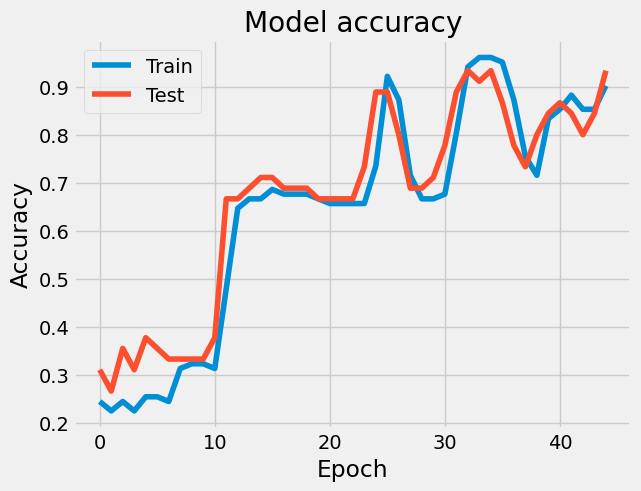

In [33]:
plt.figure()


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()

